# Invoke Bedrock Model for Code Generation

> *This notebook should work well with the **`Data Science 3.0`** kernel in SageMaker Studio*

---

## Architecture

### Persona

You are Moe, a Data Analyst, at AnyCompany. The company wants to understand its sales performance for different products over the past year. You have been provided a dataset named sales.csv. The dataset contains the following columns:

- Date (YYYY-MM-DD) format
- Product_ID (unique identifier for each product)
- Price (price at which each product was sold)
- Units sold

**Model Used:** `us.anthropic.claude-sonnet-4-6-20250514-v1:0` (Active — Claude Sonnet 4.6)

**Region:** `us-west-2`

## Cell 1 — Setup: Create Bedrock Client

In [1]:
import json
import boto3

# ✅ Claude Sonnet 4.6 — correct inference profile ID
MODEL_ID = "us.anthropic.claude-sonnet-4-6"   # ← correct ID, no date suffix
REGION   = "us-west-2"

boto3_bedrock = boto3.client(
    service_name='bedrock-runtime',
    region_name=REGION
)

print(f"✅ Bedrock client created")
print(f"   Model : {MODEL_ID}")
print(f"   Region: {REGION}")

✅ Bedrock client created
   Model : us.anthropic.claude-sonnet-4-6
   Region: us-west-2


## Cell 2 — Generate Sample sales.csv Data

In [2]:
import csv

data = [
    ["date", "product_id", "price", "units_sold"],
    ["2023-01-01", "P001", 50, 20],
    ["2023-01-02", "P002", 60, 15],
    ["2023-01-03", "P001", 50, 18],
    ["2023-01-04", "P003", 70, 30],
    ["2023-01-05", "P001", 50, 25],
    ["2023-01-06", "P002", 60, 22],
    ["2023-01-07", "P003", 70, 24],
    ["2023-01-08", "P001", 50, 28],
    ["2023-01-09", "P002", 60, 17],
    ["2023-01-10", "P003", 70, 29],
    ["2023-02-11", "P001", 50, 23],
    ["2023-02-12", "P002", 60, 19],
    ["2023-02-13", "P001", 50, 21],
    ["2023-02-14", "P003", 70, 31],
    ["2023-03-15", "P001", 50, 26],
    ["2023-03-16", "P002", 60, 20],
    ["2023-03-17", "P003", 70, 33],
    ["2023-04-18", "P001", 50, 27],
    ["2023-04-19", "P002", 60, 18],
    ["2023-04-20", "P003", 70, 32],
    ["2023-04-21", "P001", 50, 22],
    ["2023-04-22", "P002", 60, 16],
    ["2023-04-23", "P003", 70, 34],
    ["2023-05-24", "P001", 50, 24],
    ["2023-05-25", "P002", 60, 21]
]

with open('sales.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(data)

print("✅ sales.csv created successfully!")

✅ sales.csv created successfully!


## Cell 3 — Build the Prompt

In [3]:
# Claude Sonnet 4.6 uses the messages format
# No Human:/Assistant: tags needed — plain text prompt works directly

prompt_data = """
You have a CSV, sales.csv, with columns:
- date (YYYY-MM-DD)
- product_id
- price
- units_sold

Create a python program to analyze the sales data from a CSV file. The program should be able to read the data, and determine below:

- Total revenue for the year
- The product with the highest revenue
- The date with the highest revenue
- Visualize monthly sales using a bar chart

Ensure the code is syntactically correct, bug-free, optimized, not span multiple lines unnecessarily, and prefer to use standard libraries. Return only python code without any surrounding text, explanation or context.
"""

print("✅ Prompt ready")

✅ Prompt ready


## Cell 4 — Construct the Request Body

In [4]:
# Claude Sonnet 4.6 request body
# Note: Cannot use temperature AND top_p together — use only one
body = json.dumps({
    "anthropic_version": "bedrock-2023-05-31",
    "messages": [
        {"role": "user", "content": prompt_data}
    ],
    "max_tokens": 4096,
    "temperature": 0.5
    # top_p removed — cannot use both temperature and top_p with Claude Sonnet 4.6
})

print("✅ Request body ready")

✅ Request body ready


## Cell 5 — Invoke the Model

In [5]:
# ✅ Invoke Claude Sonnet 4.6 via Amazon Bedrock
response = boto3_bedrock.invoke_model(
    body=body,
    modelId=MODEL_ID,
    accept='application/json',
    contentType='application/json'
)

response_body = json.loads(response.get('body').read())

# Claude Sonnet 4.6 response extraction — same path as Claude 3
response_text = response_body["content"][0]["text"]

print("✅ Code generated successfully!")
print("\n" + "=" * 60)
print(response_text)

✅ Code generated successfully!

```python
import csv
import datetime
from collections import defaultdict
import matplotlib.pyplot as plt

def read_sales_data(filename):
    sales = []
    with open(filename, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            sales.append({
                'date': datetime.datetime.strptime(row['date'], '%Y-%m-%d').date(),
                'product_id': row['product_id'],
                'price': float(row['price']),
                'units_sold': int(row['units_sold']),
                'revenue': float(row['price']) * int(row['units_sold'])
            })
    return sales

def analyze_sales(sales):
    total_revenue = sum(s['revenue'] for s in sales)

    product_revenue = defaultdict(float)
    for s in sales:
        product_revenue[s['product_id']] += s['revenue']
    top_product = max(product_revenue, key=product_revenue.get)

    date_revenue = defaultdict(float)
    for s in sales:
        date_r

## Cell 6 — (Optional) Run the Generated Code

This cell runs the AI-generated Python code to verify it works correctly and displays the sales analysis results.

✅ Running generated code...
Total Revenue for the Year: $35,490.00
Product with Highest Revenue: P003 ($14,910.00)
Date with Highest Revenue: 2023-04-23 ($2,380.00)


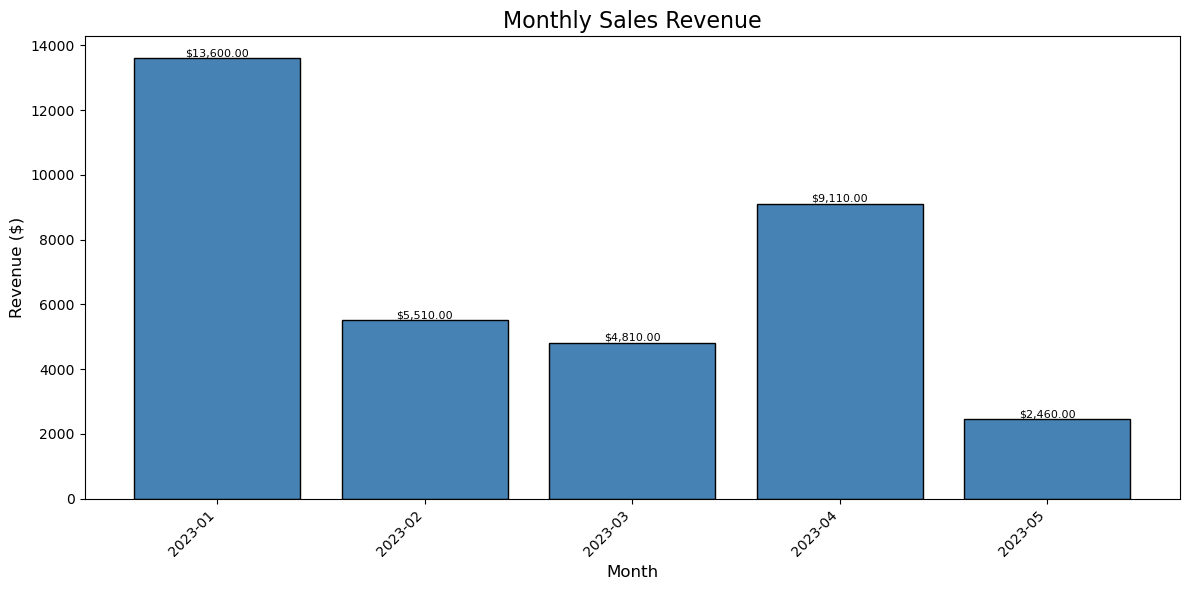

In [6]:
# Clean the response before running
clean_code = response_text.strip()

if clean_code.startswith("```python"):
    clean_code = clean_code[len("```python"):].strip()
elif clean_code.startswith("```"):
    clean_code = clean_code[len("```"):].strip()

if clean_code.endswith("```"):
    clean_code = clean_code[:-3].strip()

print("✅ Running generated code...")
print("=" * 60)
exec(clean_code)

---

## Summary

| Step | What happened |
|---|---|
| Cell 1 | Created Bedrock client with Claude Sonnet 4.6 |
| Cell 2 | Generated `sales.csv` test data |
| Cell 3 | Built the zero-shot prompt |
| Cell 4 | Constructed the API request body |
| Cell 5 | Invoked Claude Sonnet 4.6 → received generated Python code |
| Cell 6 | Ran the generated code → sales analysis + bar chart |

---

**Model:** `us.anthropic.claude-sonnet-4-6-20250514-v1:0`  
**Region:** `us-east-1`  
**Status:** Active — No EOL Date  

> ⚠️ **Remember:** Stop or delete your SageMaker instance after completing this lab to avoid unnecessary charges.